Dependencies: `pandas`.

#### Setup

Exploratory parsing of the original dataset.

In [63]:
%pip install pandas
%pip install matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [64]:
#set the datapath and dataset
DATA_PATH = "../data/bank-additional-full.csv"
ds = pd.read_csv(DATA_PATH, sep=";")

#confirming basic info about ds
print("Shape:\n", ds.shape)
print("Column types:\n", ds.info)

Shape:
 (41188, 21)
Column types:
 <bound method DataFrame.info of        age          job  marital            education  default housing loan    contact month day_of_week  duration  campaign  pdays  previous     poutcome  emp.var.rate  cons.price.idx  \
0       56    housemaid  married             basic.4y       no      no   no  telephone   may         mon       261         1    999         0  nonexistent           1.1          93.994   
1       57     services  married          high.school  unknown      no   no  telephone   may         mon       149         1    999         0  nonexistent           1.1          93.994   
2       37     services  married          high.school       no     yes   no  telephone   may         mon       226         1    999         0  nonexistent           1.1          93.994   
3       40       admin.  married             basic.6y       no      no   no  telephone   may         mon       151         1    999         0  nonexistent           1.1          93.

### Column infos

Unique Values

In [65]:
print(f"{"Column":<15} Unique Values")
for col in ds.columns:
    print(f"{col:<15} {ds[col].nunique()}")
    

Column          Unique Values
age             78
job             12
marital         4
education       8
default         3
housing         3
loan            3
contact         2
month           10
day_of_week     5
duration        1544
campaign        42
pdays           27
previous        8
poutcome        3
emp.var.rate    10
cons.price.idx  26
cons.conf.idx   26
euribor3m       316
nr.employed     11
y               2


Top Value Counts, Averages

In [66]:
for col in ds.columns:
    print(f"{col}, Unique Values: {ds[col].nunique()}")
    print(f"{ds[col].value_counts()[:5].to_string()}")
    print(f"Mean: {ds[col].mean() if pd.api.types.is_numeric_dtype(ds[col]) else 'N/A'}\n")

age, Unique Values: 78
age
31    1947
32    1846
33    1833
36    1780
35    1759
Mean: 40.02406040594348

job, Unique Values: 12
job
admin.         10422
blue-collar     9254
technician      6743
services        3969
management      2924
Mean: N/A

marital, Unique Values: 4
marital
married     24928
single      11568
divorced     4612
unknown        80
Mean: N/A

education, Unique Values: 8
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
Mean: N/A

default, Unique Values: 3
default
no         32588
unknown     8597
yes            3
Mean: N/A

housing, Unique Values: 3
housing
yes        21576
no         18622
unknown      990
Mean: N/A

loan, Unique Values: 3
loan
no         33950
yes         6248
unknown      990
Mean: N/A

contact, Unique Values: 2
contact
cellular     26144
telephone    15044
Mean: N/A

month, Unique Values: 10
month
may    13769
jul     7174
aug     6178
jun 

Missing Data

In [67]:
print("\n[1] 'unknown' counts per column")
unknown = (ds.drop(columns="y") == "unknown").sum()
print(unknown[unknown > 0].sort_values(ascending=False))


[1] 'unknown' counts per column
default      8597
education    1731
housing       990
loan          990
job           330
marital        80
dtype: int64


### Analyses

In [106]:
# new boolean column for subscription
ds["subscribed"] = ds["y"].eq("yes")

Sub Rate Formula

In [107]:
def rate_by(col, data=ds):
    return data.groupby(col)["y"].apply(
        lambda values: values.eq("yes").mean())

Sub Rate by Education Level

In [108]:
print("\n[2] Subscription rate by education (incl. unknown)")
# Ensure the boolean target column exists before grouping
print(rate_by("education").sort_values(ascending=False))



[2] Subscription rate by education (incl. unknown)
education
illiterate             0.222222
unknown                0.145003
university.degree      0.137245
professional.course    0.113485
high.school            0.108355
basic.4y               0.102490
basic.6y               0.082024
basic.9y               0.078246
Name: y, dtype: float64


Sub rate by previous campaign outcome

In [109]:
print("\n[3] Subscription rate by poutcome")
print(rate_by("poutcome"))


[3] Subscription rate by poutcome
poutcome
failure        0.142286
nonexistent    0.088322
success        0.651129
Name: y, dtype: float64


pdays previously contacted vs not 

In [110]:
print("\n[4] Previously contacted (pdays != 999) vs not")
print(rate_by(ds["pdays"].ne(999).rename("previously_contacted")))


[4] Previously contacted (pdays != 999) vs not
previously_contacted
False    0.092582
True     0.638284
Name: y, dtype: float64


Subscription by Age


[5] Subscription rate by age interval
age
(15,20]     0.453333
(20,25]     0.223565
(25,30]     0.144751
(30,35]     0.110072
(35,40]     0.091048
(40,45]     0.080220
(45,50]     0.078090
(50,55]     0.097255
(55,60]     0.107014
(60,65]     0.300000
(65,70]     0.474227
(70,75]     0.405000
(75,80]     0.529412
(80,85]     0.521739
(85,90]     0.500000
(90,95]     0.428571
(95,100]    0.666667
Name: y, dtype: float64


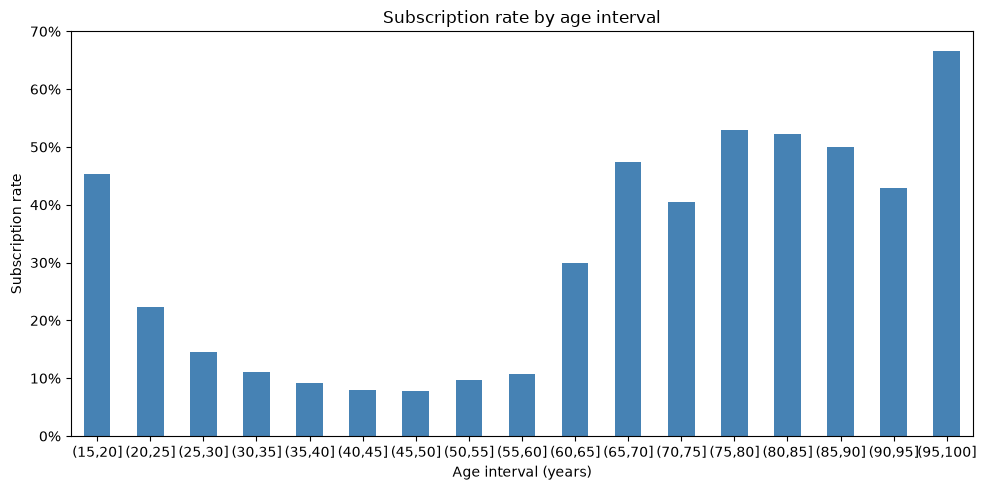

In [111]:

print("\n[5] Subscription rate by age interval")
n = 5
age_bins = np.arange(0, 101, n) #create bins from 0 to 100 in increments of n
age_labels = [f"({start},{start + (n)}]" for start in age_bins[:-1]]
age_band = pd.cut(ds["age"], bins=age_bins, right=False, labels=age_labels)

age_rates = rate_by(age_band)
print(age_rates)

# create the bar plot for subscription rate by age band
ageplot = age_rates.plot(kind="bar", figsize=(10, 5), color="steelblue")
ageplot.set(
    xlabel="Age interval (years)",
    ylabel="Subscription rate",
    title="Subscription rate by age interval",
)
ageplot.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


This is interesting because it kind of looks like it could be an inverted gaussian model.

Subscription rate by # of contacts

In [118]:
print(rate_by(ds["campaign"].clip(upper=15).rename("campaign_capped")))

campaign_capped
1     0.130371
2     0.114570
3     0.107471
4     0.093927
5     0.075047
6     0.076609
7     0.060413
8     0.042500
9     0.060071
10    0.053333
11    0.067797
12    0.024000
13    0.043478
14    0.014493
15    0.017241
Name: y, dtype: float64


Poisson of # of contacts by probability

lambda: 2.567592502670681
poisson_pmf:
pmf[0]: 0.07672002652489147, iteration: 1
pmf[1]: 0.19698576491000713, iteration: 2
pmf[2]: 0.2528895865578918, iteration: 3
pmf[3]: 0.21643913548317706, iteration: 4
pmf[4]: 0.1389318753877823, iteration: 5
pmf[5]: 0.07134408832552942, iteration: 6
pmf[6]: 0.030530424382417366, iteration: 7
pmf[7]: 0.011198526963949854, iteration: 8
pmf[8]: 0.003594156734199139, iteration: 9
pmf[9]: 0.0010253699871281164, iteration: 10
pmf[10]: 0.00026327322914136843, iteration: 11
pmf[11]: 6.145257902702525e-05, iteration: 12
pmf[12]: 1.3148765098297297e-05, iteration: 13
pmf[13]: 2.596974668135851e-06, iteration: 14
pmf[14]: 4.762837633950922e-07, iteration: 15


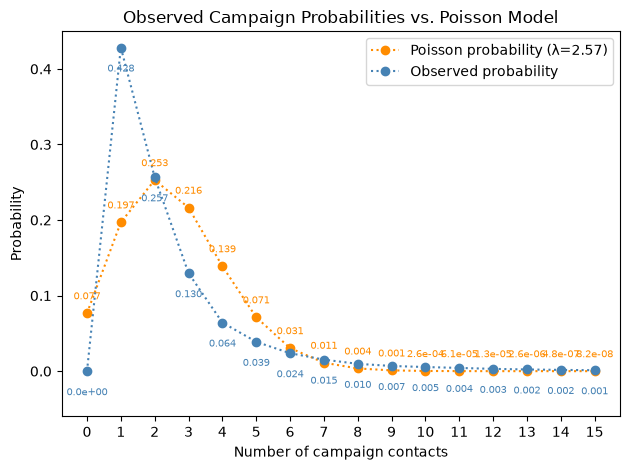

Observed probability shown (0–15): 0.991
Poisson probability shown (0–15): 1.000


In [156]:
campaign_counts = ds["campaign"]
lam = campaign_counts.mean() #lamda is orignially the mean of the campaign counts, but can be changed to any value for comparison
print(f"lambda: {lam}")

#this poisson PMF only calcs upto the max_contacts value listed, you can change it to different values
#average expected events on an integer (lambda) decreases as counts increase
#total probability values add up to 1
# Compare observed probabilities with a Poisson model for counts 0 through max_contacts.

max_contacts = 15
k = np.arange(max_contacts + 1)

poisson_pmf = np.empty(len(k)) #create empty array for PMF values
# pmf of k=0 has e^-lam to initialize because you cant divide by 0
poisson_pmf[0] = np.exp(-lam) #initialize value for PMF at k=0

# for every value of k
#     calc the corresponding pmf value by
        # (previous pmf * full campaign mean (lamda)) / kth count
print("poisson_pmf:")
for i in range(1, len(k)):
    print(f"pmf[{i - 1}]: {poisson_pmf[i - 1]}, iteration: {i}")
    poisson_pmf[i] = poisson_pmf[i - 1] * lam / i

# Observed probability = records with k contacts / all records.
observed_probs = campaign_counts.value_counts(normalize=True).reindex(k, fill_value=0)

#plot the lines and points
plt.plot(
    k,
    poisson_pmf,
    "o:",
    color="darkorange",
    label=f"Poisson probability (λ={lam:.2f})",
)
plt.plot(
    k,
    observed_probs,
    "o:",
    color="steelblue",
    label="Observed probability",
)
# put labels on opposite sides of each point and color them to match
for x, probability in zip(k, poisson_pmf):
    label = f"{probability:.3f}" if probability >= 0.0005 else f"{probability:.1e}"
    plt.annotate(
        label,
        (x, probability),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=7,
        color="darkorange",
    )
for x, probability in zip(k, observed_probs):
    label = f"{probability:.3f}" if probability >= 0.0005 else f"{probability:.1e}"
    plt.annotate(
        label,
        (x, probability),
        textcoords="offset points",
        xytext=(0, -12),
        ha="center",
        va="top",
        fontsize=7,
        color="steelblue",
    )

plt.xlabel("Number of campaign contacts")
plt.ylabel("Probability")
plt.title("Observed Campaign Probabilities vs. Poisson Model")
plt.xticks(k)
plt.ylim(bottom=-0.06)
plt.legend()
plt.tight_layout()
plt.show()

# print the observed and poisson probability sums to confirm they are both close to 1
print(f"Observed probability shown (0–{max_contacts}): {observed_probs.sum():.3f}")
print(f"Poisson probability shown (0–{max_contacts}): {poisson_pmf.sum():.3f}")

**THIS DOES NOT ANSWER OUR PREDICTIVE QUESTION**

This is about the distribution of contact counts comparing observed records against estimated by poisson

This is just showing if it fits a poisson model kinda well

The two probabilities come from different sources:

**Observed probability** at 𝑘 contacts: number of records with exactly 𝑘 contacts divided by the total number of records.

**Poisson probability** at 𝑘 contacts: the model’s estimate, calculated as

$$
P(X = k) = \frac{e^{-\lambda}\,\lambda^{k}}{k!}, \qquad k = 0, 1, 2, \dots
$$, where 𝜆 is set to the average number of contacts in the data.
But, because you cant divide by zero when X = 0,
$$
P(X = 0) = \frac{e^{-\lambda}\,\lambda^{0}}{0!}=e^{-\lambda}
$$

Their difference comes from comparing the real data with a simplified model. A Poisson distribution assumes events happen independently at a consistent average rate. The campaign data may not follow those assumptions: for example, the dataset contains customers who were contacted, so it has no zero-contact records, while a standard Poisson model assigns some probability to zero contacts. Differences between the curves show where the model’s predicted distribution doesn’t match the observed one.

